# ANÁLISE DE DADOS CHINA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# HOW CHINA LENDS

In [4]:
df = pd.read_excel("data/How_China_Lends_Dataset_Version_2_0.xlsx", sheet_name="ContractData")

Truncar

In [32]:
def truncar(label, max_chars=35):
    return label if len(label) <= max_chars else label[:max_chars] + "..."

### Verificações

In [ ]:
df.shape

In [ ]:
df.head()

In [ ]:
df.columns

In [ ]:
df.describe()

In [ ]:

df.isnull().sum()

## SEPARANDO OS CREDORES

In [35]:
df_credores = df.copy()  # copia o df original
df_credores["creditor_name"] = df_credores["creditor_name"].str.split("; ")
df_credores = df_credores.explode("creditor_name")
df_credores["creditor_name"] = df_credores["creditor_name"].str.strip()



print(df_credores.shape)

(519, 55)


### Exploração Básica ("setagem" da região)

In [4]:
df["borrower_country"].value_counts()

regiao = df["borrower_region"].value_counts()
print(regiao)

borrower_region
Latin America and the Caribbean    111
Sub-Saharan Africa                 109
Europe and Central Asia             49
East Asia and Pacific               46
Middle East and North Africa        34
South Asia                          17
North America                        5
Name: count, dtype: int64


### Preparação da coluna anos (uma "variável")

In [5]:
df["year"] = df["contract_id"].str.extract(r"_(\d{4})_").astype(int)
ultimo_ano = df["year"].max()
ultimosanos = df[df["year"] >= ultimo_ano - 13]

## Gráficos:

### 10 PAÍSES QUE MAIS RECEBERAM CONTRATOS DE EMPRÉSTIMO

borrower_country
Ecuador      38
Cameroon     23
Uganda       22
Ghana        18
Iran         18
Mongolia     16
Pakistan     16
Serbia       16
Argentina    15
Guyana       11
Name: count, dtype: int64


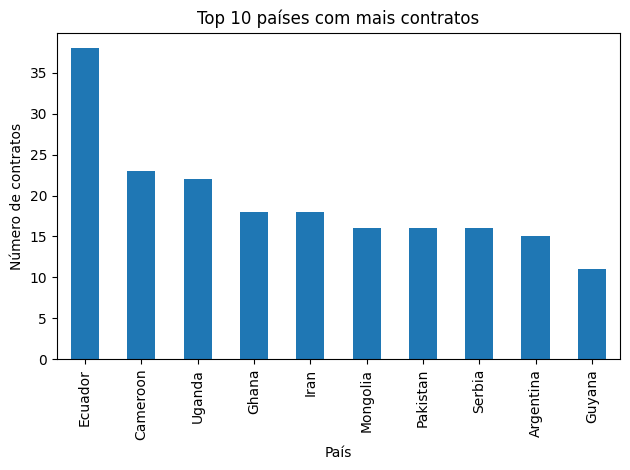

In [ ]:
pais = df["borrower_country"].value_counts().head(10)
print(pais)
pais.plot(kind="bar")
plt.title("Top 10 países com mais contratos")
plt.xlabel("País")
plt.ylabel("Número de contratos")
plt.tight_layout()
plt.show()


### Contrato por região

borrower_region
Latin America and the Caribbean    111
Sub-Saharan Africa                 109
Europe and Central Asia             49
East Asia and Pacific               46
Middle East and North Africa        34
South Asia                          17
North America                        5
Name: count, dtype: int64


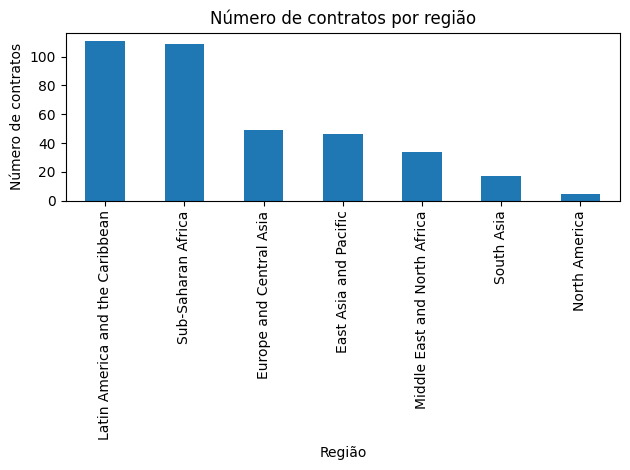

In [21]:
regiao.plot(kind="bar")
plt.title("Número de contratos por região")
plt.xlabel("Região")
plt.ylabel("Número de contratos")
plt.tight_layout()
print(regiao)
plt.show()

### 10 países por valor total (USD) de empréstimos

borrower_country
Brazil           30.459541
Ecuador          25.853733
Argentina        18.083686
Venezuela        16.042716
Singapore        14.115200
Bahamas          12.250000
Iraq             10.000000
Israel            9.500000
Kenya             8.605095
United States     7.087412
Name: commitment_USD, dtype: float64


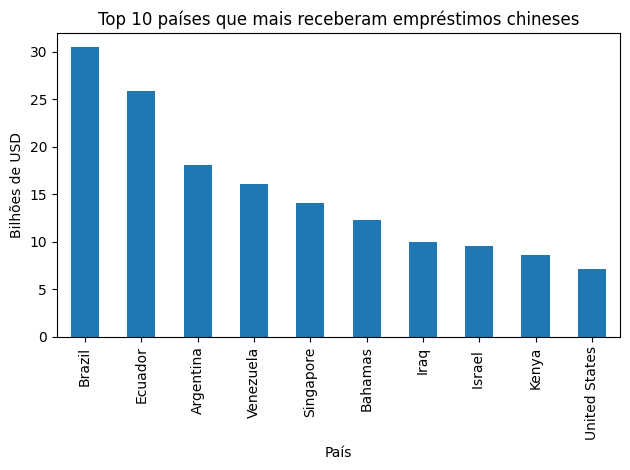

In [20]:
top10_geral = (
    df.groupby("borrower_country")["commitment_USD"]
    .sum()
    .sort_values(ascending=False)
    .head(10) / 1e9
)
top10_geral.plot(kind="bar")
plt.title("Top 10 países que mais receberam empréstimos chineses")
plt.ylabel("Bilhões de USD")
plt.xlabel("País")
plt.tight_layout()
print(top10_geral)
plt.show()

### 10 países por valor total (USD) de empréstimos - últimos 13 anos

borrower_country
Argentina        17.418690
Ecuador          11.149785
Iraq             10.000000
Israel            9.500000
Kenya             8.605095
United States     7.087412
Kazakhstan        5.778058
Uganda            4.812979
Ghana             4.612473
Serbia            4.586386
Name: commitment_USD, dtype: float64


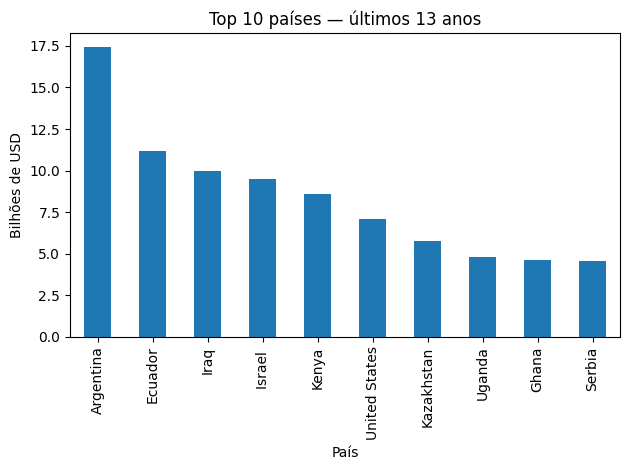

In [19]:
top10_recente = (
    ultimosanos.groupby("borrower_country")["commitment_USD"]
    .sum()
    .sort_values(ascending=False)
    .head(10) / 1e9
)
top10_recente.plot(kind="bar")
plt.title("Top 10 países — últimos 13 anos")
plt.ylabel("Bilhões de USD")
plt.xlabel("País")
plt.tight_layout()
print(top10_recente)
plt.show()

### Regiões por valor total (USD) de empréstimos - últimos 13 anos

borrower_region
Latin America and the Caribbean    35.780368
Sub-Saharan Africa                 26.694662
Middle East and North Africa       19.500000
Europe and Central Asia            18.578280
North America                       7.543003
East Asia and Pacific               6.932258
South Asia                          4.319680
Name: commitment_USD, dtype: float64


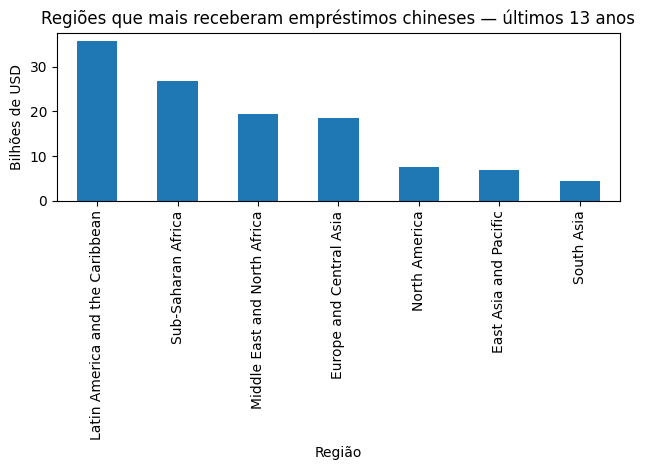

In [18]:
region = (
    ultimosanos.groupby("borrower_region")["commitment_USD"]
    .sum()
    .sort_values(ascending=False) / 1e9
)
region.plot(kind="bar")
plt.title("Regiões que mais receberam empréstimos chineses — últimos 13 anos")
plt.ylabel("Bilhões de USD")
plt.xlabel("Região")
plt.tight_layout()
print(region)
plt.show()

### América Latina - últimos 13 anos

País
Argentina     17.418690
Ecuador       11.149785
Bahamas        2.450000
Colombia       1.050000
Nicaragua      0.988004
Costa Rica     0.798150
Guyana         0.774978
Brazil         0.459541
Honduras       0.297720
Barbados       0.192500
Panama         0.060000
Suriname       0.050000
Paraguay       0.050000
Uruguay        0.030000
Jamaica        0.011000
Name: Empréstimos (bilhões USD), dtype: float64


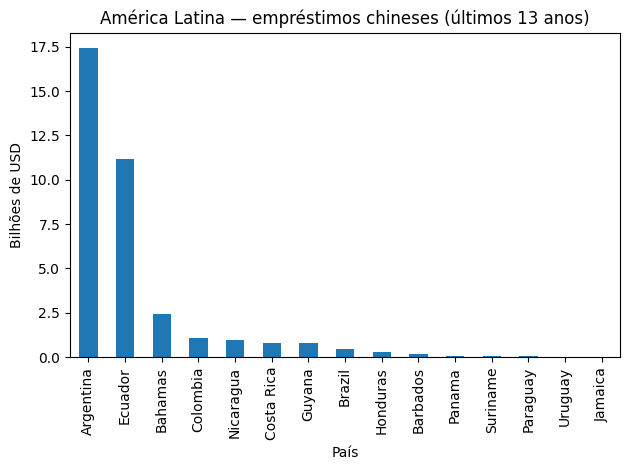

In [43]:
latam = ultimosanos[ultimosanos["borrower_region"] == "Latin America and the Caribbean"]
ranking = (
    latam.groupby("borrower_country")["commitment_USD"]
    .sum()
    .sort_values(ascending=False) / 1e9
)

ranking.index.name = "País"
ranking.name = "Empréstimos (bilhões USD)"
ranking.plot(kind="bar")
plt.title("América Latina — empréstimos chineses (últimos 13 anos)")
plt.ylabel("Bilhões de USD")
plt.xlabel("País")
print(ranking)
plt.tight_layout()
plt.show()

### Brasil ao longo do tempo

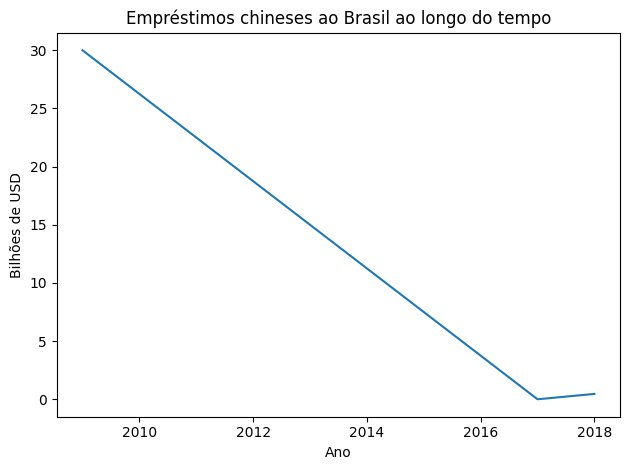

In [5]:
brasil = df[df["borrower_country"] == "Brazil"]
(brasil.groupby("year")["commitment_USD"].sum() / 1e9).plot()
plt.title("Empréstimos chineses ao Brasil ao longo do tempo")
plt.ylabel("Bilhões de USD")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

### O mundo ao longo do tempo

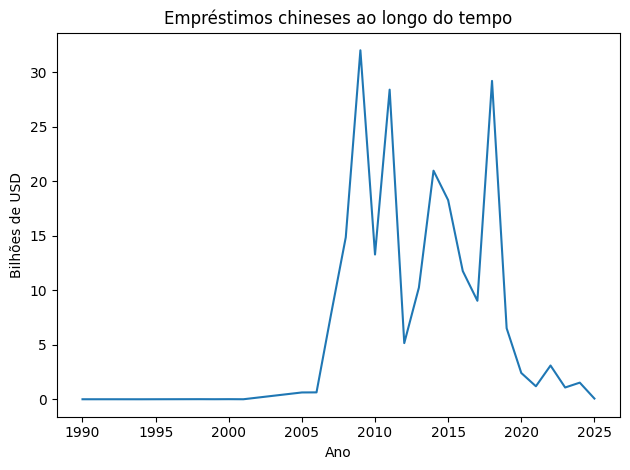

In [6]:
(df.groupby("year")["commitment_USD"].sum() / 1e9).plot()
plt.title("Empréstimos chineses ao longo do tempo")
plt.ylabel("Bilhões de USD")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

### 10 credores com maior número de contratos no mundo

Credor
Export-Import Bank of China                                                                                                                                      234
China Development Bank                                                                                                                                            42
ICBC                                                                                                                                                              18
Bank of China Ltd.                                                                                                                                                18
Inter-American Development Bank acting on behalf of the People's Bank of China (PBOC) through the China Co-Financing Fund for Latin America and the Caribbean     14
China's Ministry of Commerce (MOFCOM)                                                                                                                             11
Sin

C:\Users\nick_\AppData\Local\Temp\ipykernel_9552\3809156923.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


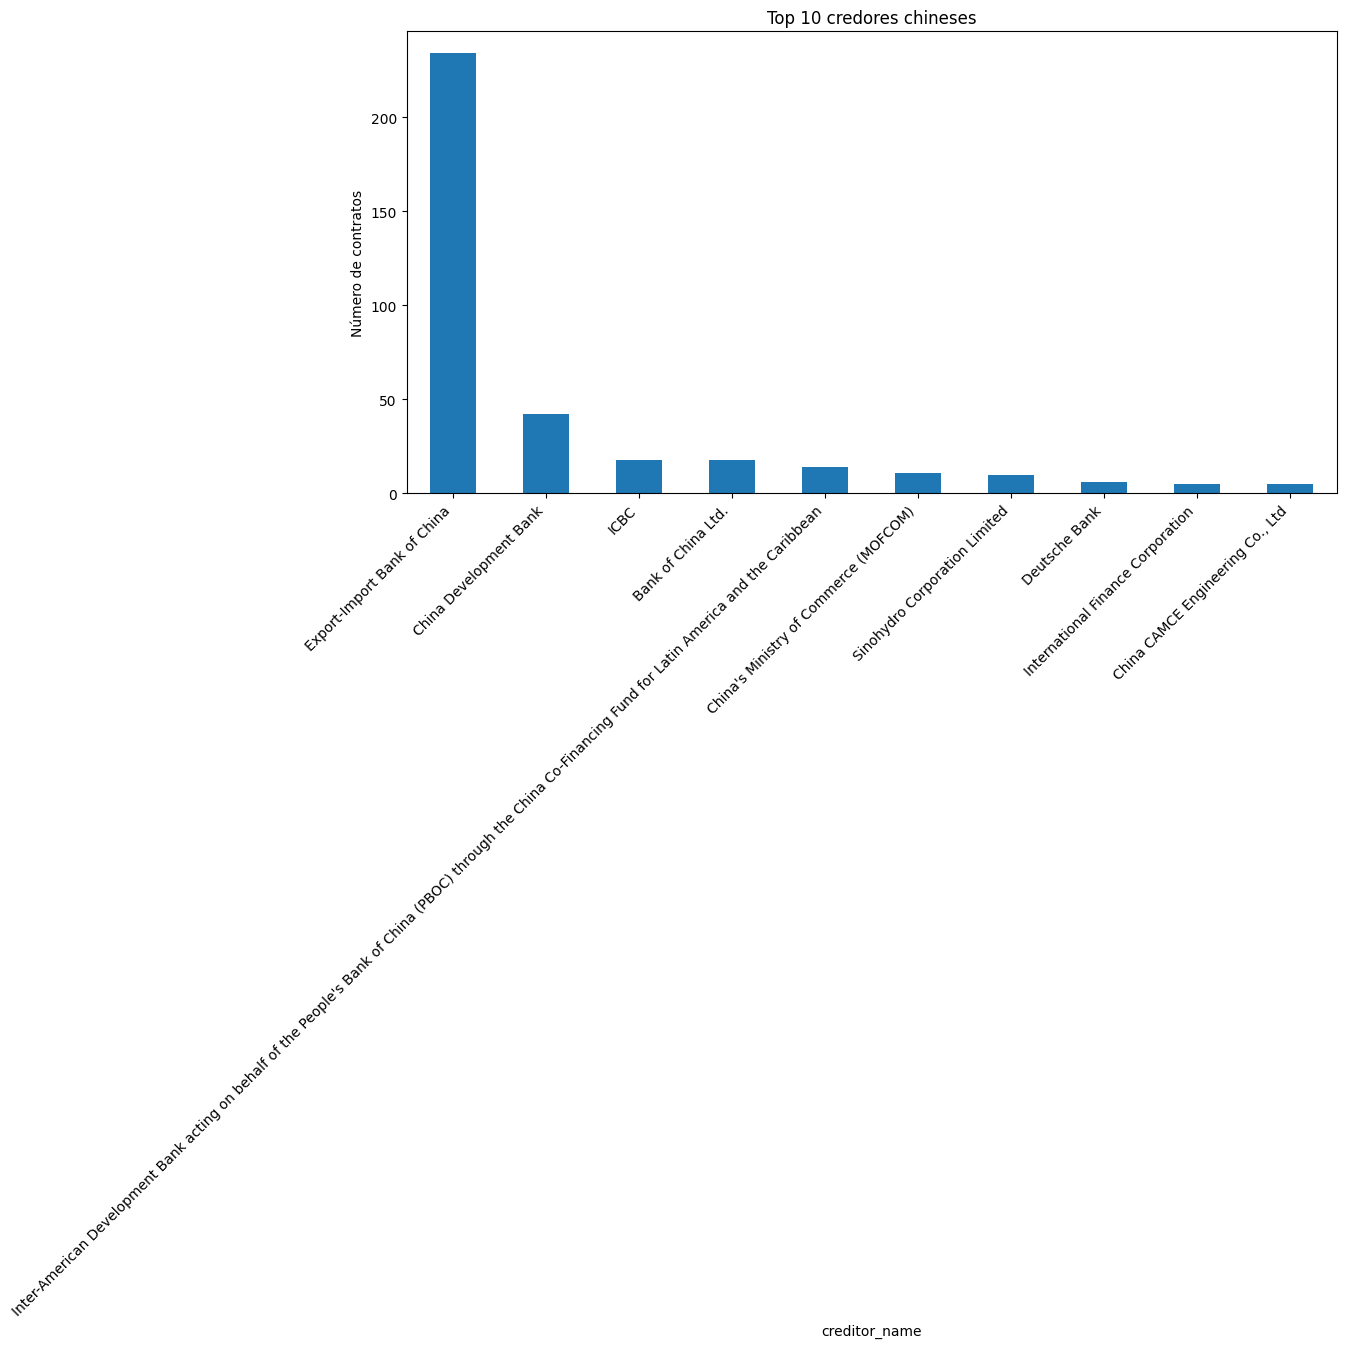

In [ ]:
credores_separados = (
    df["creditor_name"]
    .str.split("; ")   
    .explode()         
    .str.strip()       
)
resultado = credores_separados.value_counts().head(10)
resultado.index.name = "Credor"
resultado.name = "Número de Contratos"
print(resultado)

plt.figure(figsize=(12, 6))
credores_separados.value_counts().head(10).plot(kind="bar")
plt.title("Top 10 credores chineses")
plt.ylabel("Número de contratos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Os 10 maiores credores - USD


borrower_region                  creditor_name                                      
Latin America and the Caribbean  China Development Bank                                 64.802816
Sub-Saharan Africa               Export-Import Bank of China                            21.325278
Latin America and the Caribbean  Export-Import Bank of China                            20.242242
East Asia and Pacific            China Development Bank                                 15.701000
Latin America and the Caribbean  Bank of China Ltd.                                     14.966808
                                                                                          ...    
                                 China's Ministry of Commerce (MOFCOM)                   0.030757
East Asia and Pacific            DNB Bank ASA                                            0.030000
                                 China's Ministry of Commerce (MOFCOM)                   0.008491
Europe and Central Asia          

C:\Users\nick_\AppData\Local\Temp\ipykernel_12728\842978342.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


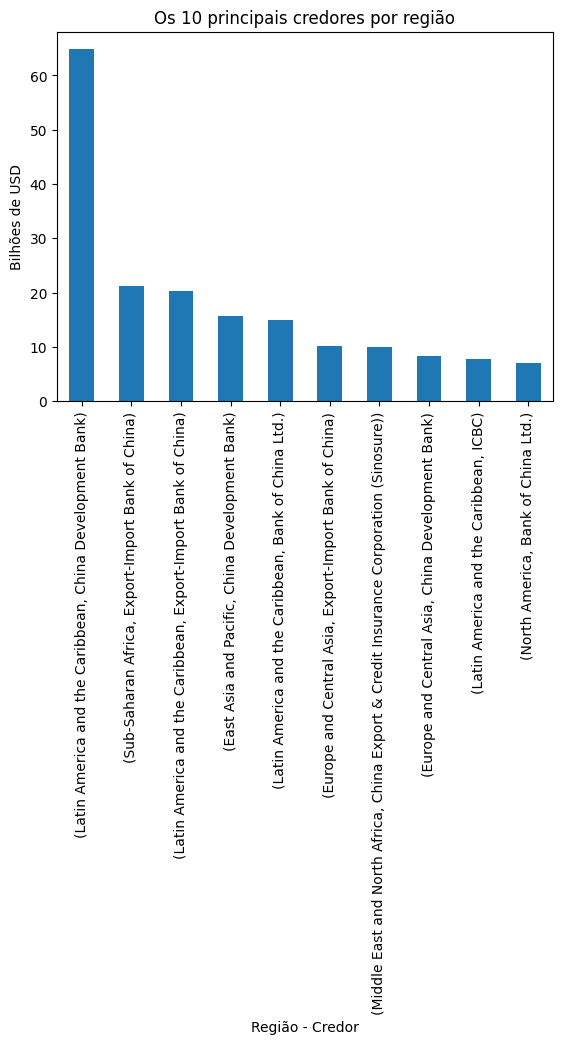

In [30]:
ranking_regiao = (
    df_credores.groupby(["borrower_region", "creditor_name"])["commitment_USD"]
    .sum()
    .sort_values(ascending=False) / 1e9
)

ranking_regiao.index.name = "Credor"
ranking_regiao.name = "Os 10 principais credores por região"
print(ranking_regiao)

ranking_regiao.head(10).plot(kind="bar")
plt.title("Os 10 principais credores por região")
plt.ylabel("Bilhões de USD")
plt.xlabel("Região - Credor")

plt.tight_layout()
plt.show()

### Média por credores com o mínimo de 5 contratos

Credor
China Development Bank                                                                                                                                           2.622811
Bank of China Ltd.                                                                                                                                               1.684594
ICBC                                                                                                                                                             1.179141
International Finance Corporation                                                                                                                                0.317528
Export-Import Bank of China                                                                                                                                      0.297717
Sinohydro Corporation Limited                                                                                                                  

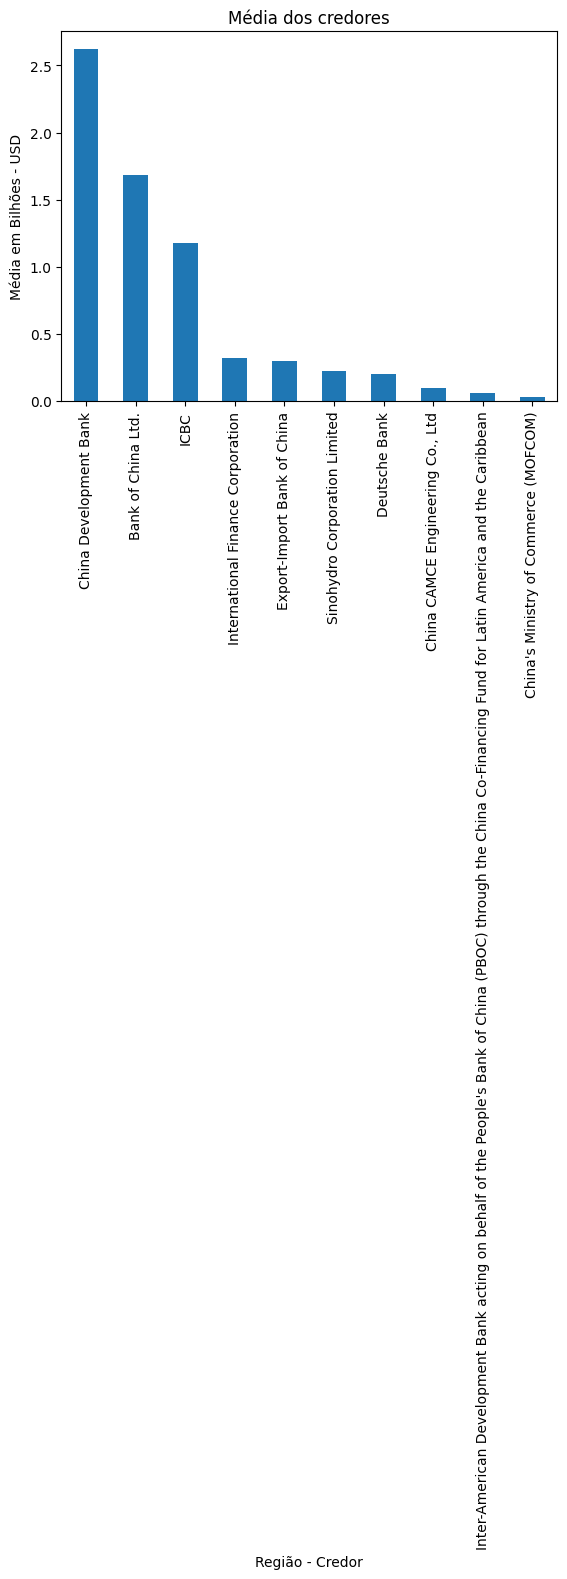

In [8]:
# Conta quantos contratos cada credor tem
contagem = df_credores["creditor_name"].value_counts()

# Filtra só credores com 5+ contratos
credores_frequentes = contagem[contagem >= 5].index

media_por_credor = (
    df_credores[df_credores["creditor_name"].isin(credores_frequentes)].groupby("creditor_name")["commitment_USD"]
    .mean()
    .sort_values(ascending=False) / 1e9
).head(10)

media_por_credor.head(10).plot(kind="bar")
plt.title("Média dos credores")
plt.ylabel("Média em Bilhões - USD")
plt.xlabel("Região - Credor")


media_por_credor.index.name = "Credor"
media_por_credor.name = "Valor médio por contrato (Bilhões USD)"
print(media_por_credor)

### Média dos 10 maiores credores

### Os 10 maiores credores da América Latina e Caribe

Credor
China Development Bank                                                                                                                            64.802816
Export-Import Bank of China                                                                                                                       20.242242
Bank of China Ltd.                                                                                                                                14.966808
ICBC                                                                                                                                               7.784811
UNIPEC Asia Co., Ltd.                                                                                                                              3.100000
PetroChina Company Limited                                                                                                                         3.000000
EP Petroecuador                                          

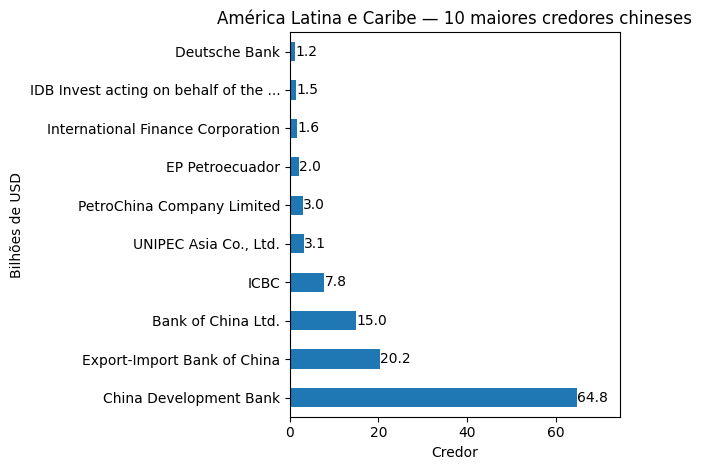

In [ ]:
latamcar_credores = df_credores[df_credores["borrower_region"] =="Latin America and the Caribbean"]

ranking_latamcaribe = (latamcar_credores.groupby("creditor_name")["commitment_USD"].sum().sort_values(ascending=False) / 1e9).head(10)



ranking_latamcaribe.index.name = "Credor"
ranking_latamcaribe.name = " 10 Principais credores da América Latina e Caribe"

print(ranking_latamcaribe)
ranking_latamcaribe.head(10).plot(kind="barh")

ax = plt.gca() # "get current axis" — pega o eixo atual, só funciona dentro de cada bloco de código, não da para setar como variável, eu tentei, ficou ruim

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2, #isso tudo aqui funciona com um barh, para funcionar com um bar normal faça:  bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,  f"{bar.get_height():.1f}", ha='center'
        f"{bar.get_width():.1f}",
        va='center'
    )



plt.title("América Latina e Caribe — 10 maiores credores chineses")
plt.ylabel("Bilhões de USD")
plt.xlabel("Credor")

ax.set_xlim(0, ranking_latamcaribe.max() * 1.15)

ax.set_yticklabels([truncar(t.get_text()) for t in ax.get_yticklabels()]) #truncar gráficos únicos
plt.tight_layout()
plt.show()

### Os maiores credores por região

In [ ]:
ranking = (df.groupby (["borrower_region", "creditor_name"])["commitment_USD"]).sum().sort_values(ascending=False) / 1e9 
print(ranking.head(10))

ranking.head(10).plot(kind="bar")
plt.title("América Latina — empréstimos chineses (últimos 13 anos)")
plt.ylabel("Bilhões de USD")
plt.xlabel("Região - Credor")

plt.tight_layout()
plt.show()

### Quantas vezes o China Development Bank aparece em contratos sindicalizados

In [89]:
df_credores["syndicated_commercial"].value_counts()
cdb_sind = df_credores[(df_credores["syndicated_commercial"] == 1) & (df_credores["creditor_name"] == "China Development Bank")
]

#Alteração leve nos valores
df_dolar_cdb = cdb_sind[["borrower_country", "creditor_name", "commitment_USD", "project_title"]].copy()

df_dolar_cdb["commitment_USD"] = df_dolar_cdb["commitment_USD"] / 1e9



print("=== Contratos sindicalizados do CDB ===")
print(df_dolar_cdb)

print("\n=== Valor total potencialmente duplicado ===")
print(cdb_sind["commitment_USD"].sum() / 1e9)


=== Contratos sindicalizados do CDB ===
    borrower_country           creditor_name  commitment_USD  \
93    Cayman Islands  China Development Bank         0.49500   
224           Greece  China Development Bank         0.12258   

                                         project_title  
93   Drillship Construction Project\nFRONTIER BULLY...  
224  Acquisition of Fakarava, Rangiroa, and Rangiro...  

=== Valor total potencialmente duplicado ===
0.61758


### Comparações com subplots

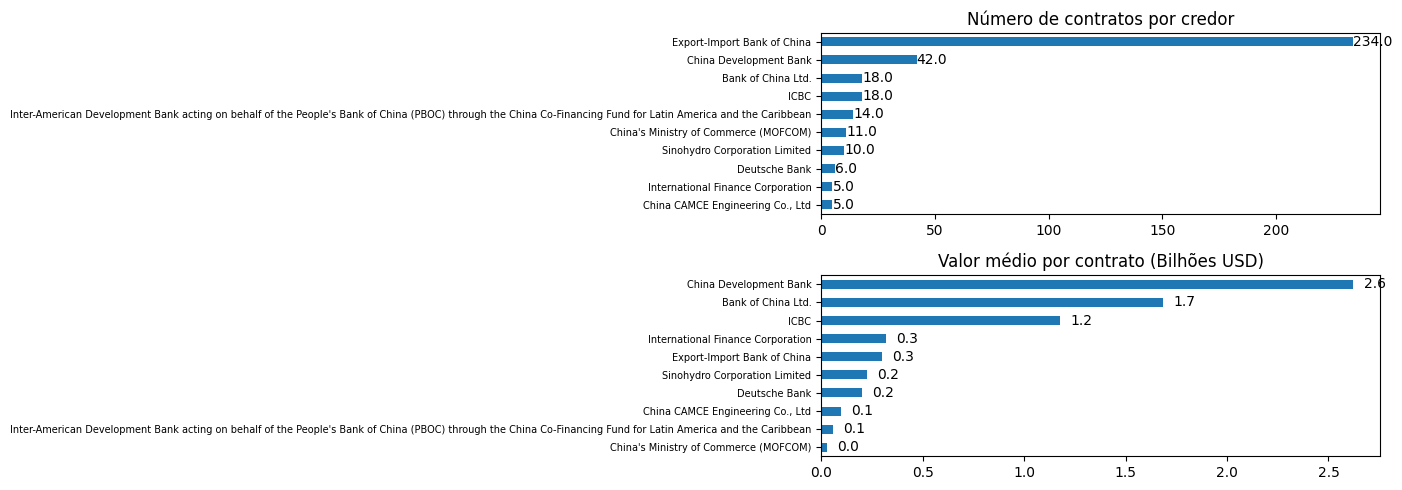

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# Gráfico da esquerda
contagem.head(10).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Número de contratos por credor")
axes[0].set_ylabel("")

for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )

# Gráfico da direita
media_por_credor.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Valor médio por contrato (Bilhões USD)")
axes[1].set_ylabel("")  

for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )




axes[0].tick_params(axis='y', labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

### Comparação - últimos 13 anos

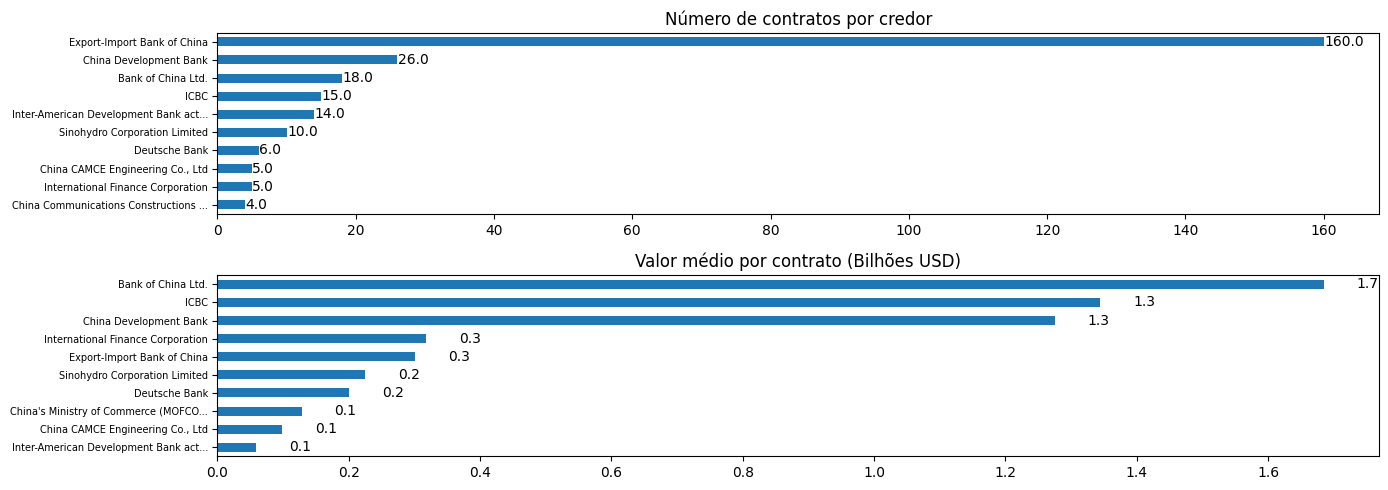

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

df_credores["year"] = df_credores["contract_id"].str.extract(r"_(\d{4})_").astype(int)
ano = df_credores["year"].max()
periodo_max = df_credores[df_credores["year"] >= ano - 13]

media_contrato_ano = periodo_max["creditor_name"].value_counts().head(10)

media_contrato_ano.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Número de contratos por credor")
axes[0].set_ylabel("")

for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )

media_credores_ano = (
    periodo_max[periodo_max["creditor_name"].isin(credores_frequentes)]
    .groupby("creditor_name")["commitment_USD"]
    .mean()
    .sort_values(ascending=False) / 1e9
).head(10)
media_credores_ano.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Valor médio por contrato (Bilhões USD)")
axes[1].set_ylabel("")

for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )



axes[0].tick_params(axis='y', labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)
axes[0].set_yticklabels([truncar(t.get_text()) for t in axes[0].get_yticklabels()])
axes[1].set_yticklabels([truncar(t.get_text()) for t in axes[1].get_yticklabels()])


plt.tight_layout()
plt.show()

    

# DADOS DO "GLOBAL CHINESE DEVELOPMENT FINANCE"


In [5]:
gcdf = pd.read_excel("data/AidDatasGlobalChineseDevelopmentFinanceDataset_v2.0.xlsx", sheet_name="Global_CDF2.0")

In [6]:
gcdf.shape

(13427, 70)

In [ ]:
gcdf.head()

In [ ]:
gcdf.columns.tolist()

### Regiões dos Empréstimos

In [16]:
regioes = gcdf["Recipient Region"].value_counts()

regioes.index.name ="Regiões"
regioes.name="Regiões que mais receberam empréstimos"
print(regioes)


Regiões
Africa          6313
Asia            3405
America         1628
Oceania          915
Europe           698
Middle East      434
Multi-Region      34
Name: Regiões que mais receberam empréstimos, dtype: int64


### Valores por região

In [ ]:
valor_regiao = gcdf.groupby("Recipient Region")["Amount (Constant USD2017)"].sum().sort_values(ascending=False) / 1e9
valor_regiao.index.name="Regiões"
valor_regiao.name="Valor por região"
print(valor_regiao)
valor_regiao.plot(kind="bar")
plt.title("Valor por região em Bilhões - USD")
plt.ylabel("Bilhões em USD")
plt.xlabel("Região")
plt.show()

### Subplot dos dados de cima

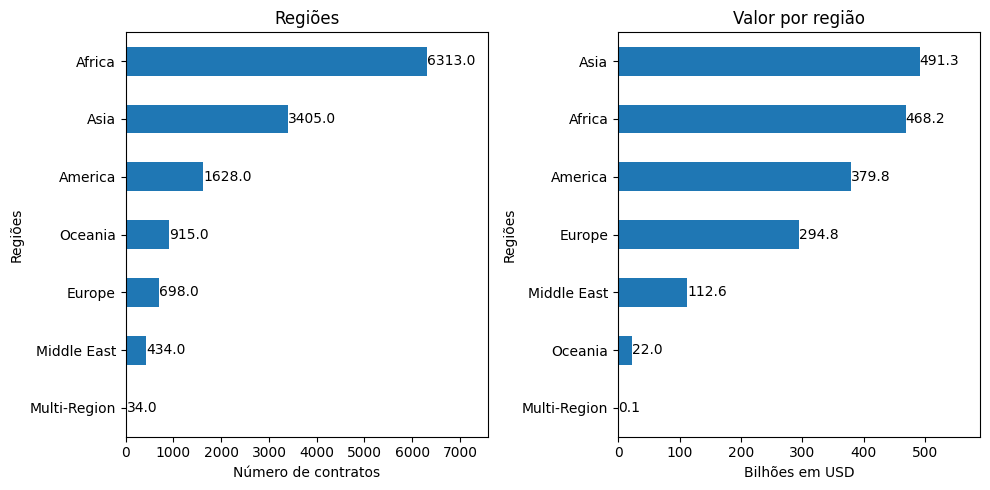

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

#Gráfico da esquerda - Regiões
regioes.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Regiões")
axes[0].set_xlabel("Número de contratos")
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )
axes[0].set_xlim(0, regioes.max() * 1.20)

#Gráfico da direita - Valor por região
valor_regiao.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Valor por região")
axes[1].set_xlabel("Bilhões em USD")
for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )
axes[1].set_xlim(0, valor_regiao.max() * 1.20)


plt.tight_layout()
plt.show()

### Setores

Setores
EDUCATION                                          1821
HEALTH                                             1530
GOVERNMENT AND CIVIL SOCIETY                       1340
TRANSPORT AND STORAGE                              1244
ENERGY                                             1063
UNALLOCATED/UNSPECIFIED                             979
EMERGENCY RESPONSE                                  924
OTHER SOCIAL INFRASTRUCTURE AND SERVICES            822
AGRICULTURE, FORESTRY, FISHING                      700
INDUSTRY, MINING, CONSTRUCTION                      690
COMMUNICATIONS                                      555
OTHER MULTISECTOR                                   505
WATER SUPPLY AND SANITATION                         301
ACTION RELATING TO DEBT                             244
DEVELOPMENTAL FOOD AID/FOOD SECURITY ASSISTANCE     159
Name: Quantidade de Empréstimos por Setor, dtype: int64


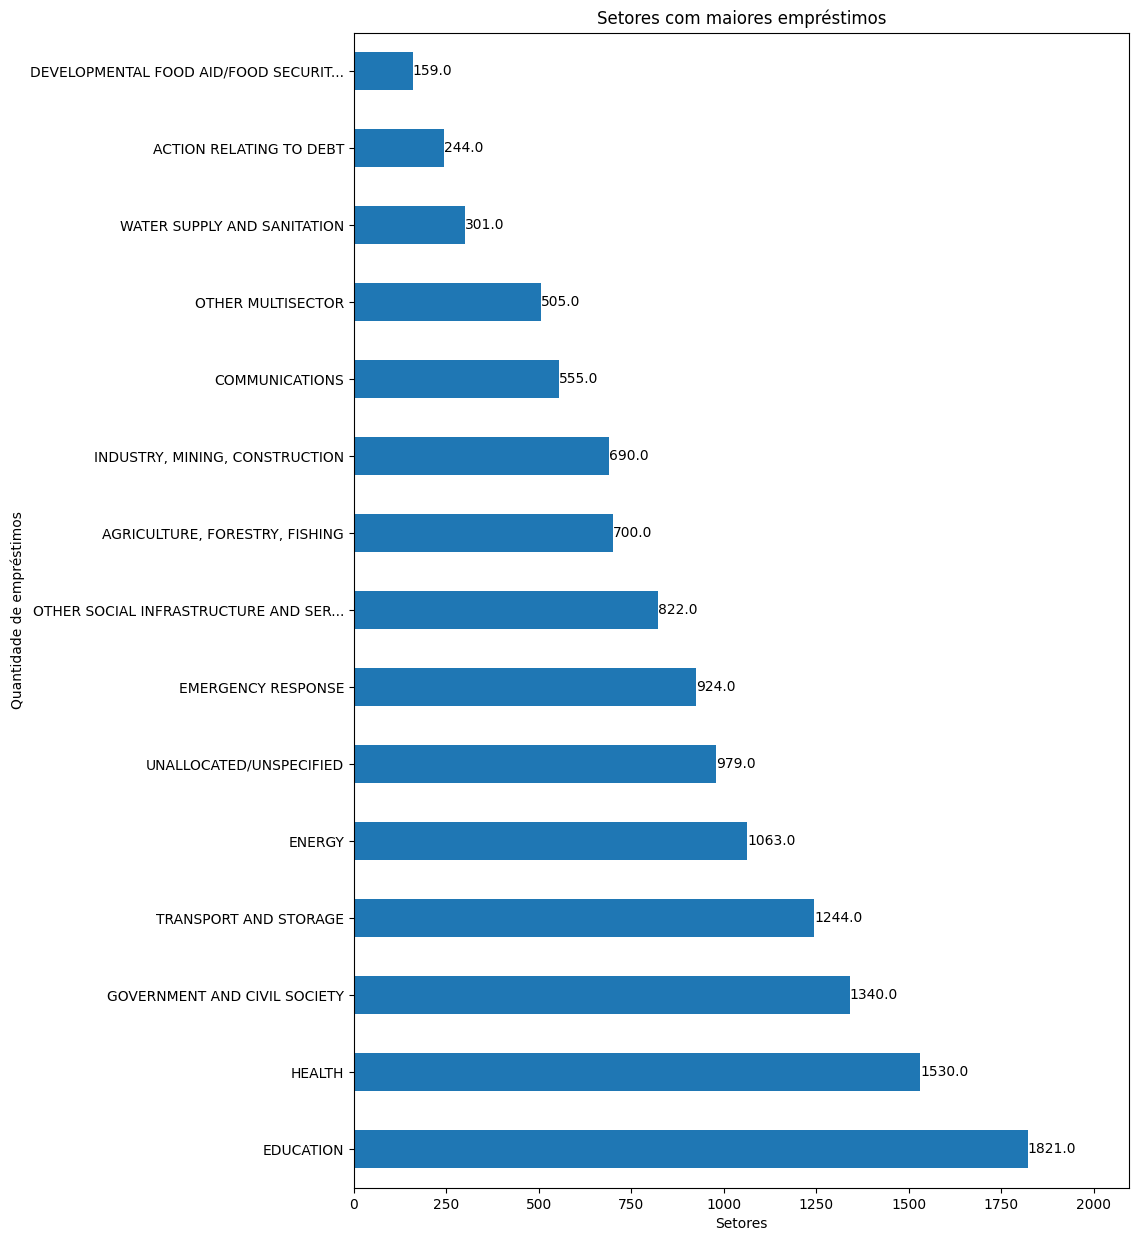

In [57]:
setores = gcdf["Sector Name"].value_counts().head(15)

plt.figure(figsize=(10, 15))

ax=plt.gca()

setores.index.name="Setores"
setores.name="Quantidade de Empréstimos por Setor"
print(setores)

setores.plot(kind="barh")

for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va='center'
    )

ax.set_xlim(0, setores.max() * 1.15)

ax.set_yticklabels([truncar(t.get_text()) for t in ax.get_yticklabels()])
plt.title("Setores com maiores empréstimos")
plt.ylabel("Quantidade de empréstimos")
plt.xlabel("Setores")
plt.show()

### Valor por setores

In [ ]:
valor_setores = gcdf.groupby("Sector Name")["Amount (Constant USD2017)"].sum().sort_values(ascending=False)/1e9

print(valor_setores)


### O que é "Other Multisector"?

In [62]:
for texto in gcdf[gcdf["Sector Name"] == "OTHER MULTISECTOR"]["Description"].head(5):
    print(texto)
    print("---")

On 17 May 2017, the China Development Bank signed a financing agreement with Argentinian Bank BICE (Banco de Inversión y Comercio Exterior) extending a $150 million USD line of credit to on-lend to local borrowers for projects that promote agro-industrial exports from SMEs in Argentina and explore sustainable energy sources as well as the investment projects undertaken by Chinese companies established in Argentina (See: Annual Report 2017). The loan has 7 years maturity, a  2 years grace period, and a low interest-rate of around 3% (See: El BICE cerró un acuerdo en China para financiar a pymes por USD 150 millones).According to the 2018 Annual Report from BICE, as of 31 December 2018, the bank had drawn down the full $150 million USD credit. $50 million USD were drawn down by the bank on 26 October 2017, $42 million USD were drawn down on 22 December 2017, and $58 million USD were drawn down by the bank on 5 July 2018, for a total of $150 million USD drawn down of the $150 million USD 

### Exclusão do "Other Multisector"

In [68]:
setores_valor = gcdf[gcdf["Sector Name"] != "OTHER MULTISECTOR"].groupby("Sector Name")["Amount (Constant USD2017)"].sum().sort_values(ascending=False).head(10) / 1e9

print(setores_valor)

Sector Name
ENERGY                                      374.630258
INDUSTRY, MINING, CONSTRUCTION              358.305572
TRANSPORT AND STORAGE                       252.858330
UNALLOCATED/UNSPECIFIED                      54.837204
COMMUNICATIONS                               50.617394
OTHER SOCIAL INFRASTRUCTURE AND SERVICES     46.837063
GENERAL BUDGET SUPPORT                       38.771598
BANKING AND FINANCIAL SERVICES               35.539151
ACTION RELATING TO DEBT                      23.127307
AGRICULTURE, FORESTRY, FISHING               20.931342
Name: Amount (Constant USD2017), dtype: float64
